### In this nootbook I will plot the performance of the 16-64 layer model (minimodel) trained on data in the experanto format

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from minimodel import data, metrics, model_builder, model_trainer

results_path_16_64 = './results_16-64_exp_test_set_seed'
results_path_16_320 = './results_16-320_exp_test_set_seed2'
output_path = './outputs'
device = torch.device('cuda')

In [2]:
FEV_scores_mini_all = []
FEVE_scores_mini_all = []
FEV_scores_full_all = []
FEVE_scores_full_all = []

for mouse_id in range (6):
    # get the paths
    file_name = "results_" + str(mouse_id) + ".npz"
    results_file_path = os.path.join(results_path_16_64, file_name)
    data_mini = np.load(results_file_path)

    results_file_path = os.path.join(results_path_16_320, file_name)
    data_full = np.load(results_file_path)

    # get the arrays
    FEV_scores_mini = data_mini["FEV_scores"].squeeze()
    FEVE_scores_mini = data_mini["FEVE_scores"].squeeze()
    neurons_index_mini = data_mini["neurons_index"].squeeze()

    FEV_scores_full = data_full["FEV_scores"]
    FEVE_scores_full = data_full["FEVE_scores"]
    neurons_index_full = data_full["neurons_index"]

    selected_FEV_scores_full = FEV_scores_full[neurons_index_mini]
    selected_FEVE_scores_full = FEVE_scores_full[neurons_index_mini]

    # append arrays
    FEV_scores_mini_all.append(FEV_scores_mini)
    FEVE_scores_mini_all.append(FEVE_scores_mini)
    FEV_scores_full_all.append(selected_FEV_scores_full)
    FEVE_scores_full_all.append(selected_FEVE_scores_full)

FEV_scores_mini_all = np.array(FEV_scores_mini_all)
FEVE_scores_mini_all = np.array(FEVE_scores_mini_all)
FEV_scores_full_all = np.array(FEV_scores_full_all)
FEVE_scores_full_all = np.array(FEVE_scores_full_all)

In [3]:
print(f"FEVE_scores_mini_all: {FEVE_scores_mini_all.shape}")
print(f"FEVE_scores_full_all: {FEVE_scores_full_all.shape}")
FEVE_scores_mini_flat = FEVE_scores_mini_all.flatten()
FEVE_scores_full_flat = FEVE_scores_full_all.flatten()
FEV_scores_full_flat = FEV_scores_full_all.flatten()

print(f"FEVE_scores_mini_flat: {FEVE_scores_mini_flat.shape}")
print(f"FEVE_scores_full_flat: {FEVE_scores_full_flat.shape}")
print(f"FEV_scores_full_flat: {FEV_scores_full_flat.shape}")

FEVE_scores_mini_all: (6, 50)
FEVE_scores_full_all: (6, 50)
FEVE_scores_mini_flat: (300,)
FEVE_scores_full_flat: (300,)
FEV_scores_full_flat: (300,)


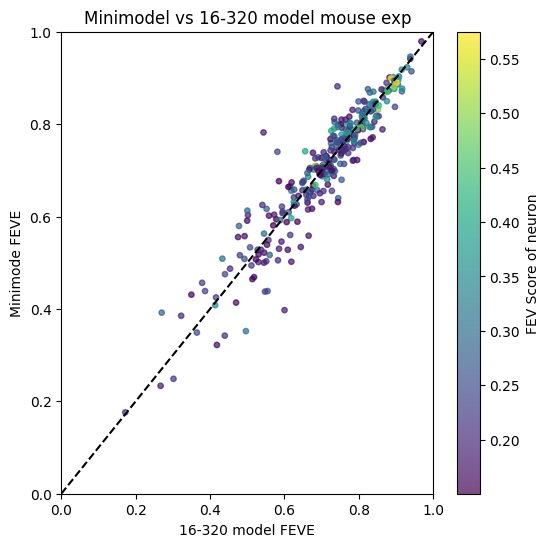

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(x=FEVE_scores_full_flat, y=FEVE_scores_mini_flat, s=15, alpha=0.7, c=FEV_scores_full_flat, cmap="viridis")
plt.colorbar(label='FEV Score of neuron')
plt.plot([0,1], linestyle="--", color="black")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.xlabel("16-320 model FEVE")
plt.ylabel("Minimode FEVE")
plt.title("Minimodel vs 16-320 model mouse exp")

output_file_path = os.path.join(output_path, "Minimodel_vs_16-320_model_exp")
plt.savefig(output_file_path)
plt.show()

In [5]:
mean_full = np.mean(FEVE_scores_full_all, axis=1)
mean_mean_full = np.mean(mean_full, axis=0)
sem_mean_full = np.std(mean_full, axis=0, ddof=1) / np.sqrt(mean_full.shape[0])


mean_mini = np.mean(FEVE_scores_mini_all, axis=1)
mean_mean_mini = np.mean(mean_mini, axis=0)
sem_mean_mini = np.std(mean_mini, axis=0, ddof=1) / np.sqrt(mean_mini.shape[0])

#print(f"shape: {FEVE_scores_full_all.shape}")
#print(f"mean_full: {mean_full.shape}")
print(f"mean_mean_full FEVE: {mean_mean_full}")
print(f"sem_mean_full FEVE: {sem_mean_full}")
#print(f"mean_mini: {mean_mini.shape}")
print(f"mean_mean_mini FEVE: {mean_mean_mini}")
print(f"sem_mean_mini FEVE: {sem_mean_mini}")


mean_mean_full FEVE: 0.7065777258476277
sem_mean_full FEVE: 0.011807014812708601
mean_mean_mini FEVE: 0.7059788279526019
sem_mean_mini FEVE: 0.016306402785772132


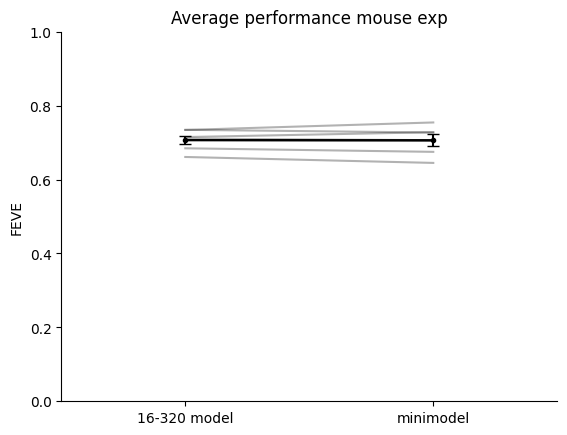

In [6]:
for mice_id in range(0,6):
    y = [mean_full[mice_id], mean_mini[mice_id]]
    plt.plot(y, color="BLACK", alpha=0.3)

y = [mean_mean_full, mean_mean_mini]
y_sem = [sem_mean_full, sem_mean_mini]
plt.plot(y, marker="o", markersize= 3, color="BLACK")
plt.errorbar(
    [0,1],
    y,
    yerr=y_sem,
    capsize=4,
    color = "BLACK"
)

tick_labels = ['16-320 model', 'minimodel']
plt.xticks([0,1],tick_labels)
plt.xlim(-0.5, 1.5)
plt.ylim(0.0, 1.0)

plt.ylabel("FEVE")
plt.title("Average performance mouse exp")
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

output_file_path = os.path.join(output_path, "Average_performance_mouse_exp")
plt.savefig(output_file_path)
plt.show()
